## Demo notebook: First steps with DJA

In [2]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd

import astropy.io.fits as pyfits
import astropy.units as u

import sep

import grizli
from grizli import utils
print(f'grizli version: {grizli.__version__}')

import msaexp
import msaexp.spectrum
print(f'msaexp version: {msaexp.__version__}')

BASE_URL = 'https://s3.amazonaws.com/msaexp-nirspec/extractions/'
PATH_TO_FILE = BASE_URL + '{root}/{file}'

grizli version: 1.14.2
msaexp version: 0.9.17


In [11]:
from astropy.table import Table

nrs = Table.read(
    '/mnt/c/Users/nicol/Desktop/Proyecto_Astronomico/Astronomical_Investigation_Project/data/nirspec_public_v4.csv.csv',
    format='ascii.csv'
)

aurora02 = (nrs['root'] == 'aurora-gdn02-v4') & (nrs['grade'] == 3)

roots = utils.Unique(nrs['root'][aurora02], verbose=False)

is_aur = np.array([f.startswith('aurora-gdn0') for f in nrs['file']])

id = '931951'

src = np.array([id in f for f in nrs['file']]) & is_aur

nrs['root','file','grating','z','grade'][src]

urls = [PATH_TO_FILE.format(**row) for row in nrs[src]]

urls

['https://s3.amazonaws.com/msaexp-nirspec/extractions/aurora-gdn02-v4/aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits',
 'https://s3.amazonaws.com/msaexp-nirspec/extractions/aurora-gdn02-v4/aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits',
 'https://s3.amazonaws.com/msaexp-nirspec/extractions/aurora-gdn02-v4/aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits']

In [32]:
from astropy.io import fits


url = urls[1]

img = pyfits.open(url)
spec = utils.GTable(img['SPEC1D'].data)
img.info()

Filename: /home/nicol/.astropy/cache/download/url/1a805ad4a3d16050005da00841d34cb6/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPEC1D        1 BinTableHDU    381   3685R x 9C   ['D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D']   
  2  SCI           1 ImageHDU       358   (3685, 31)   float64   
  3  WHT           1 ImageHDU       358   (3685, 31)   float64   
  4  PROFILE       1 ImageHDU       358   (3685, 31)   float64   
  5  PROF1D        1 BinTableHDU     25   31R x 3C   [D, D, D]   
  6  BACKGROUND    1 ImageHDU       358   (3685, 31)   float64   
  7  SLITS         1 BinTableHDU    107   12R x 49C   [67A, K, K, D, D, D, D, D, K, 11A, D, D, D, D, 3A, K, K, D, D, K, K, K, K, K, K, K, 4A, 5A, 6A, 25A, K, K, D, K, K, K, 12A, D, D, D, D, 17A, K, K, 4A, K, K, D, D]   


In [44]:
def plot_2D_from_url(url):

    # Load data

    img = pyfits.open(url)
    spec = utils.GTable(img['SPEC1D'].data)
    img.info()

    # Science Header

    for i, k in enumerate(img['SCI'].header):
        print(f"{k} : {img['SCI'].header[k]}")
        if k == 'FILE2':
            break
            
    print('...')

    # 2D Spectra Plotting

    fig, axes = plt.subplots(3,1, figsize=(8, 5), sharex=True, sharey=True)

    msk = img['WHT'].data > 0

    for i, k in enumerate(['SCI','WHT','PROFILE']):
        _data = img[k].data
        vm = np.percentile(_data[msk], [2,99])
        ax = axes[i]
        ax.imshow(_data, vmin=vm[0], vmax=vm[1], cmap='plasma_r', aspect='auto')
        ax.set_ylabel(k)
        ax.set_yticklabels([])
        
    xtv = [1,2,3,4,5]
    xti = np.interp(xtv, spec['wave'], np.arange(len(spec)))

    a2 = axes[0].twiny()
    a2.set_xlabel('pix')
    a2.set_xlim(0, _data.shape[1])

    ax.set_xticks(xti)
    ax.set_xticklabels(xtv)

    ax.set_xlabel(r'$\lambda_\mathrm{obs}\,[\mu\mathrm{m}]$')

    _ = fig.tight_layout(pad=1)

    # Optimal Extraction Profile


    p1 = utils.GTable(img['PROF1D'].data)

    fig, ax = plt.subplots(1,1,figsize=(5,3))
    ax.plot(p1['pix'], p1['profile'], label='data', color='k')
    ax.plot(p1['pix'], p1['pfit'], label='fit', color='r', lw=4, alpha=0.5)

    ax.set_xlabel(r'$\Delta y$, pix')
    ax.set_ylabel('Collapsed profile')
    ax.legend()

    ax.grid()

    # 

    wlims = [(1.8, 2.1), (5, 5.2)]
    fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

    w2d = np.ones(img['SCI'].data.shape)*spec['wave']

    for i, wlim in enumerate(wlims):
        msk = (w2d > wlim[0]) & (w2d < wlim[1]) & (img['WHT'].data > 0)
        ydata = (img['SCI'].data*msk).sum(axis=1)
        pdata = (img['PROFILE'].data*msk).sum(axis=1)
        
        anorm = (ydata*pdata).sum()/(pdata**2).sum()
        pdata *= anorm
        norm = pdata.sum()
        
        pl = ax.plot(ydata/norm, label=r'$xx < \lambda < yy$'.replace('xx', f'{wlim[0]:.1f}').replace('yy', f'{wlim[1]:.1f}'))
        ax.plot(pdata/norm, label='profile', color=pl[0].get_color(), linestyle='--')
        
    ax.set_ylim(-0.18, 0.5)
    ax.legend()
    ax.set_xlim(10,30)
    ax.grid()

In [39]:
# for url in urls:
#     print('~~~~~~~~~~~~~~~~~~~~~~~')
#     print("")
#     plot_2D_from_url(url)
#     print("")
#     print('~~~~~~~~~~~~~~~~~~~~~~~')

Filename: /home/nicol/.astropy/cache/download/url/1a805ad4a3d16050005da00841d34cb6/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPEC1D        1 BinTableHDU    381   3685R x 9C   ['D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D']   
  2  SCI           1 ImageHDU       358   (3685, 31)   float64   
  3  WHT           1 ImageHDU       358   (3685, 31)   float64   
  4  PROFILE       1 ImageHDU       358   (3685, 31)   float64   
  5  PROF1D        1 BinTableHDU     25   31R x 3C   [D, D, D]   
  6  BACKGROUND    1 ImageHDU       358   (3685, 31)   float64   
  7  SLITS         1 BinTableHDU    107   12R x 49C   [67A, K, K, D, D, D, D, D, K, 11A, D, D, D, D, 3A, K, K, D, D, K, K, K, K, K, K, K, 4A, 5A, 6A, 25A, K, K, D, K, K, K, 12A, D, D, D, D, 17A, K, K, 4A, K, K, D, D]   
XTENSION : IMAGE
BITPIX : -64
NAXIS : 2
NAXIS1 : 3685
NAXIS2 : 31
PCOUNT : 0
GCOUNT : 1
DATE : 2024-12-31T16:17:29.349
ORIGIN : STSCI
TIMESYS

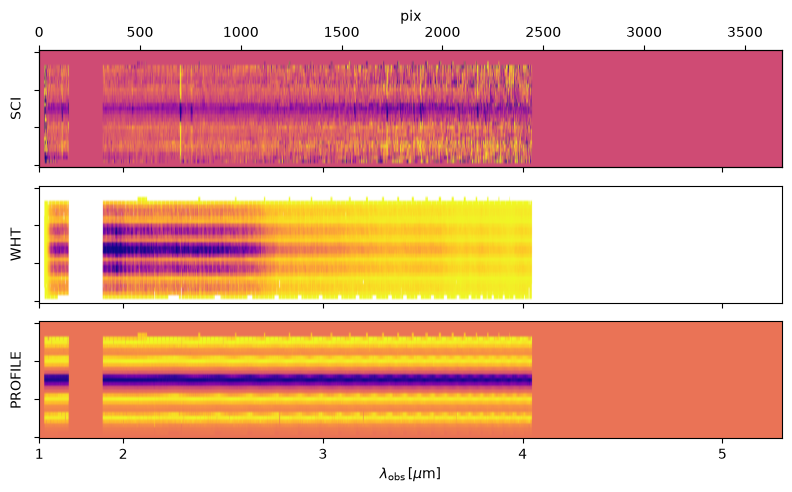

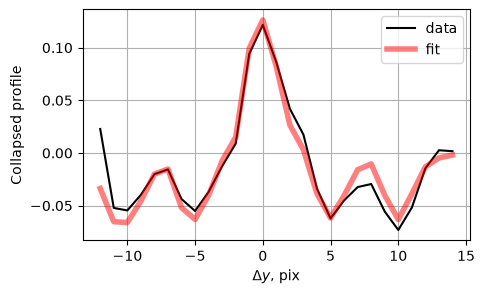

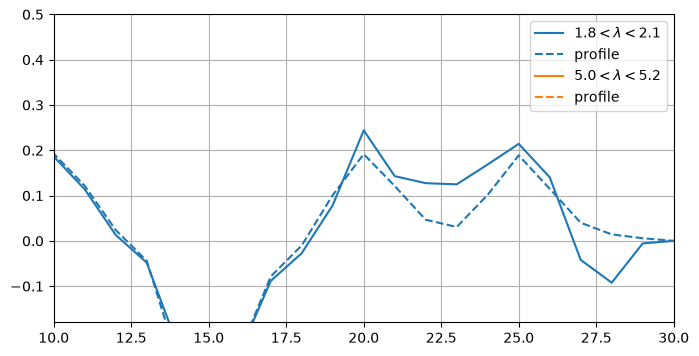

In [59]:
url = urls[1]

plot_2D_from_url(url)

In [60]:
# Open the files into 1D objects, directly from the web
sobj = {}
for u in urls:
    print(f'Read {u}')
    key = os.path.basename(u)
    sobj[key] = msaexp.spectrum.SpectrumSampler(u)

Read https://s3.amazonaws.com/msaexp-nirspec/extractions/aurora-gdn02-v4/aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits
Read https://s3.amazonaws.com/msaexp-nirspec/extractions/aurora-gdn02-v4/aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits
Read https://s3.amazonaws.com/msaexp-nirspec/extractions/aurora-gdn02-v4/aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits


In [63]:
sobj

{'aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits': <msaexp.spectrum.SpectrumSampler at 0x76811c071c10>,
 'aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits': <msaexp.spectrum.SpectrumSampler at 0x76811c944440>,
 'aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits': <msaexp.spectrum.SpectrumSampler at 0x76811de24a70>}

In [65]:
sp = sobj['aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits']
sp.spec.info()

for i, k in enumerate(sp.spec.meta):
    print(f"{k} : {sp.spec.meta[k]}")
    if k == 'CRDS2':
        break
        
print('...')

<GTable length=3685>
    name     dtype  unit                description                   class     n_bad
----------- ------- ---- ----------------------------------------- ------------ -----
       wave float64                                                      Column     0
       flux float64                                                      Column     0
        err float64                                                      Column     0
        sky float64  uJy                                           MaskedColumn  1434
  path_corr float64                                                MaskedColumn  1434
       npix float64                                                      Column     0
   flux_sum float64                                                      Column     0
profile_sum float64                                                      Column     0
    var_sum float64                                                      Column     0
       corr float64              

In [66]:
ymax = [0.8, 0.4, 0.8, 0.8]
xlimits = [(0.5, 5.4), (0.5, 2.2), (2.2, 2.8), (3.18, 3.6)]

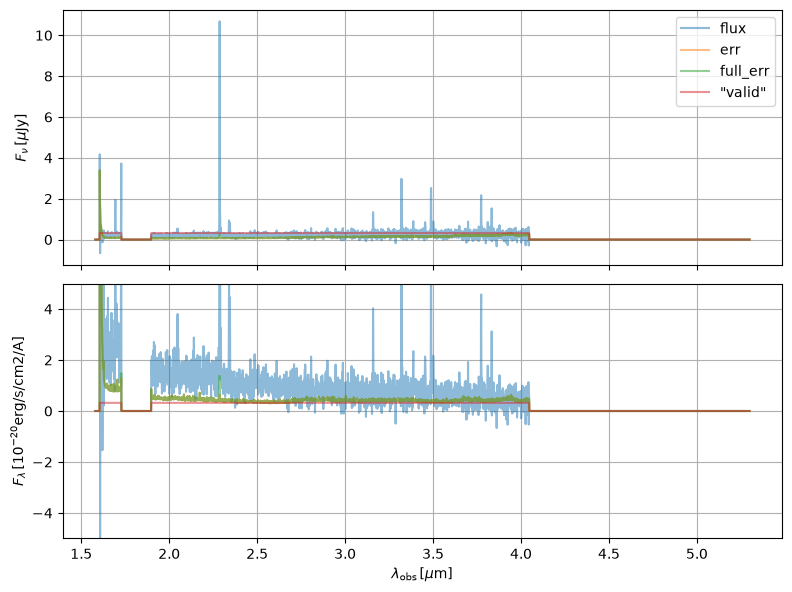

In [69]:
fig, axes = plt.subplots(2,1,figsize=(8,6), sharex=True)
ax = axes[0]

for c in ['flux','err','full_err']:
    ax.plot(sp.spec_wobs, sp.spec[c], alpha=0.5, label=c)
#ax.plot(sp.spec_wobs, sp.spec['err'], alpha=0.5, label='err')
#ax.plot(sp.spec_wobs, sp.spec['full_err'], alpha=0.5, label='full_err')

#ax.set_ylim(-0.1*ymax[1], ymax[1])
ax.plot(sp.spec_wobs, sp.valid*ymax[1]*0.8, alpha=0.5, label='"valid"')
ax.grid()
ax.legend()
ax.set_ylabel(r'$F_\nu\,[\mu\mathrm{Jy}]$')

ax = axes[1]
for c in ['flux','err','full_err']:
    ax.plot(sp.spec_wobs, sp.spec[c]*sp.spec['to_flam'], alpha=0.5, label=c)

ax.plot(sp.spec_wobs, sp.valid*ymax[1]*0.8, alpha=0.5, label='"valid"')
ax.set_ylim(-5, 5)
ax.set_ylabel(r'$F_\lambda\,[10^{-20}\mathrm{erg/s/cm2/A}]$')
ax.grid()

ax.set_xlabel(r'$\lambda_\mathrm{obs}\,[\mu\mathrm{m}]$')

_ = fig.tight_layout(pad=1)

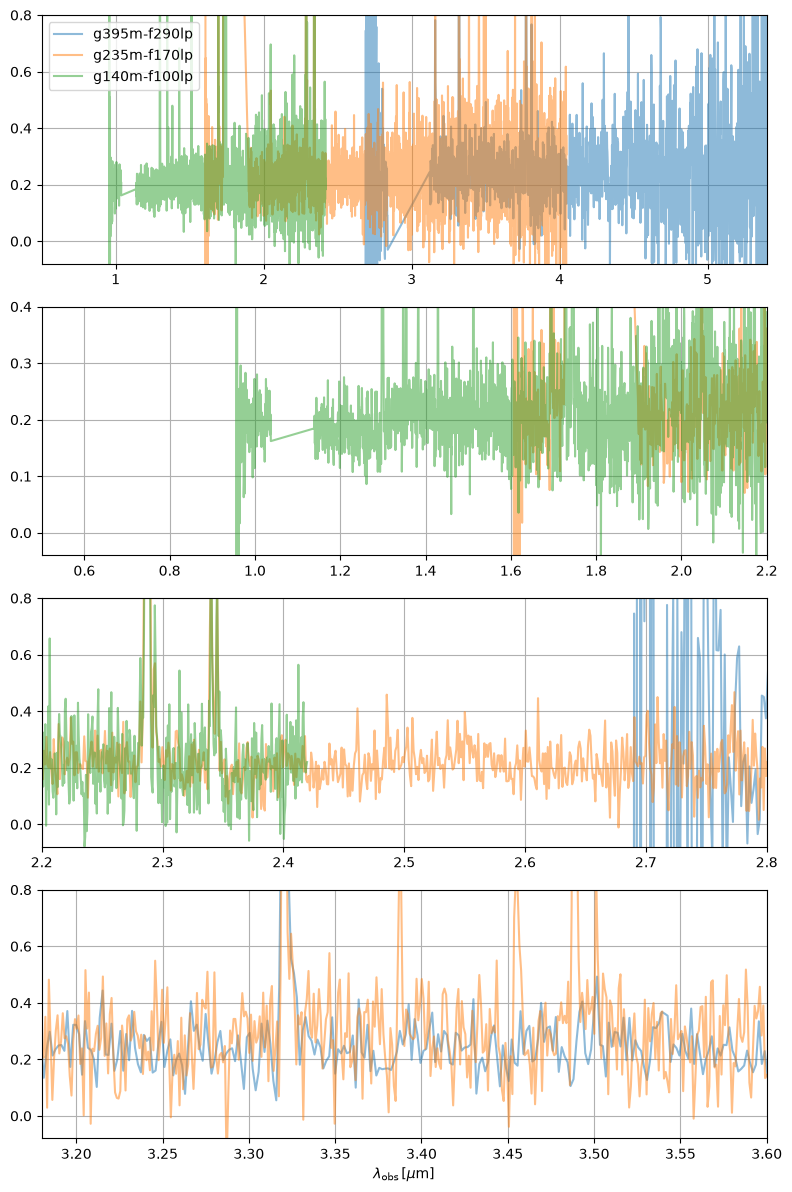

In [70]:
# Show all spectra
fig, axes = plt.subplots(len(xlimits),1,figsize=(8,3*len(xlimits)))

for ax, xlim, ym in zip(axes, xlimits, ymax):
    for i, k in enumerate(sobj):
        sp = sobj[k]
        ax.plot(sp.spec_wobs[sp.valid], sp.spec['flux'][sp.valid], alpha=0.5, label=k.split('_')[1])
    
    ax.set_xlim(*xlim)

    ax.set_ylim(-0.1*ym, ym)
    ax.grid()
    
axes[0].legend()
ax.set_xlabel(r'$\lambda_\mathrm{obs}\,[\mu\mathrm{m}]$')

_ = fig.tight_layout(pad=1)